# Lab: Demand Estimation and Industrial Organization

## Bluetooth Speakers
- The electronics product that had the nicest characteristics for our lab is: Bluetooth Speakers
- The top 5 brands are Bose, JBL, Anker, DOSS, OontZ, plus the **outside option** of Other, which are a collection of small and cheap brands with typically bad reviews
- We want to look at sales data (prices, choices) and infer whether the market is performing well for consumers: Is it competitive? Are prices reasonable or not, relative to cost?

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

## 1. EDA

Load `demand_2.parquet`. This is brand-level data, which is already consolidated from the many TB of Amazon consumer level data.

- Make kernel density plots for the price and average rating of the products, by brand, as well as describe tables grouped by brand. Which are most expensive? Which are most popular?
- Make plots of the sales, average prices, and market shares of each brand in each year

In [5]:
df = pd.read_parquet('/Users/clairicelou/Documents/DS3021/undergrad_ml_assignments/data/demand_2.parquet')

df.head()

,year,choice,chosen_users,avg_price,avg_rating,waterproof_share,party_share,voice_assistant_share,speaker_buyers,share_among_speaker_buyers
0,2015,Anker,79,63.329873,4.529114,0.000000,0.000000,0.000000,20029,0.003944
1,2015,Bose,4212,141.189855,4.533974,0.000000,0.000000,0.000000,20029,0.210295
2,2015,JBL,2832,78.035332,4.383510,0.000353,0.000000,0.000000,20029,0.141395
3,2015,OontZ,104,45.456538,3.659615,0.000000,0.000000,0.903846,20029,0.005192
4,2015,Other,12802,134.215901,4.175402,0.060381,0.084596,0.028902,20029,0.639173


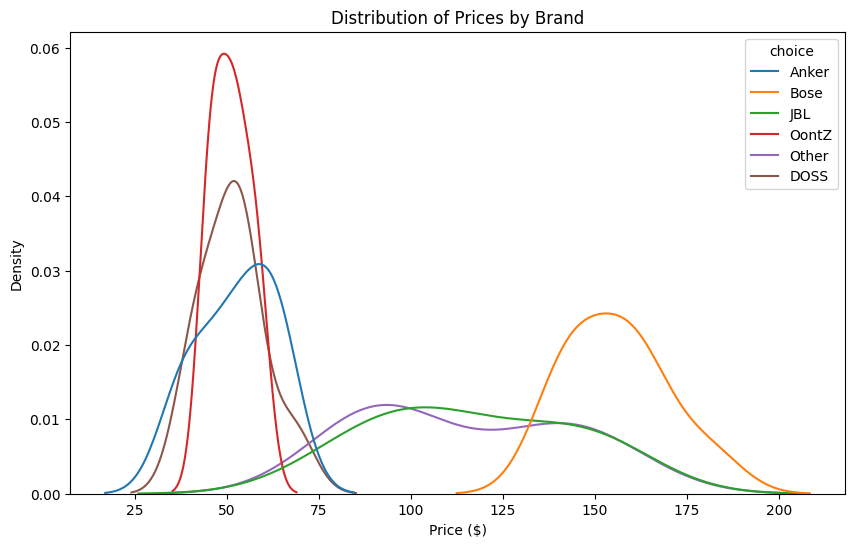

In [12]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='avg_price', hue='choice', common_norm=False)
plt.title('Distribution of Prices by Brand')
plt.xlabel('Price ($)')
plt.show()

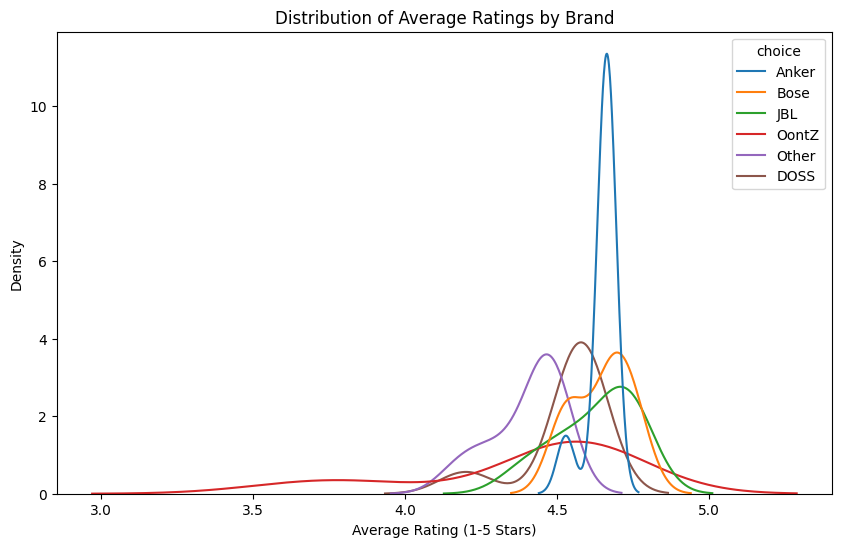

In [11]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='avg_rating', hue='choice', common_norm=False)
plt.title('Distribution of Average Ratings by Brand')
plt.xlabel('Average Rating (1-5 Stars)')
plt.show()

In [14]:
brand_summary = df.groupby('choice')[['avg_price', 'avg_rating']].describe()
print(brand_summary)

       avg_price                                                             \
           count        mean        std         min         25%         50%   
choice                                                                        
Anker        9.0   52.781417  10.475939   37.254859   45.841395   52.491460   
Bose         9.0  155.879724  13.765945  139.076504  145.759094  157.682772   
DOSS         8.0   51.576938   8.625919   41.193009   45.330259   53.325928   
JBL          9.0  116.973130  26.911164   78.035332   94.471574  111.748653   
OontZ        9.0   51.207299   5.181823   45.304602   45.833644   51.715275   
Other        9.0  114.889306  27.695630   85.083429   89.376884  104.414740   

                               avg_rating                                \
               75%         max      count      mean       std       min   
choice                                                                    
Anker    63.329873   64.223083        9.0  4.648906  0.045972  

In [16]:
avg_stats = df.groupby('choice')[['avg_price', 'avg_rating']].mean().sort_values(by='avg_price', ascending=False)
print("\nAverage Price and Rating by Brand:")
print(avg_stats)


Average Price and Rating by Brand:
         avg_price  avg_rating
choice                        
Bose    155.879724    4.647972
JBL     116.973130    4.628324
Other   114.889306    4.400181
Anker    52.781417    4.648906
DOSS     51.576938    4.531629
OontZ    51.207299    4.386703


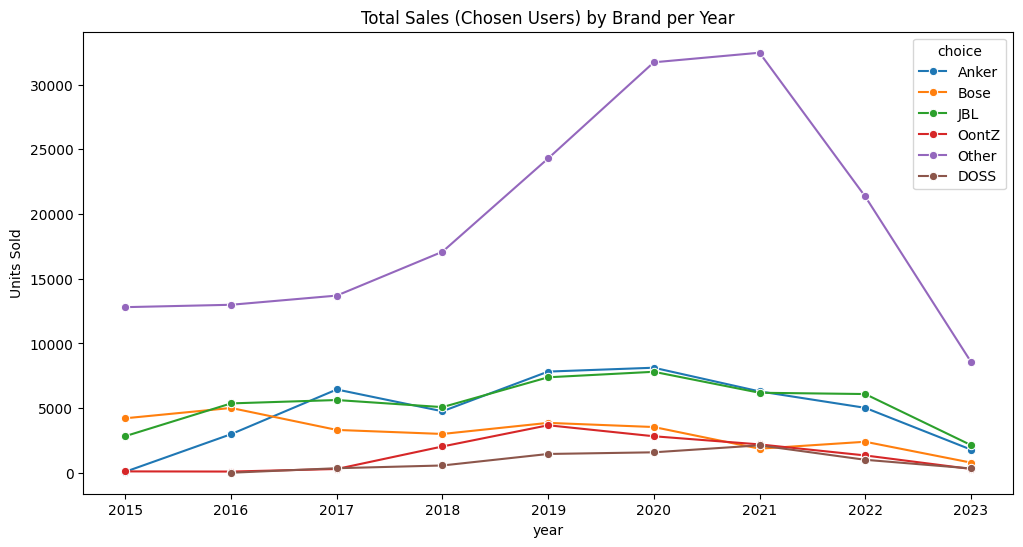

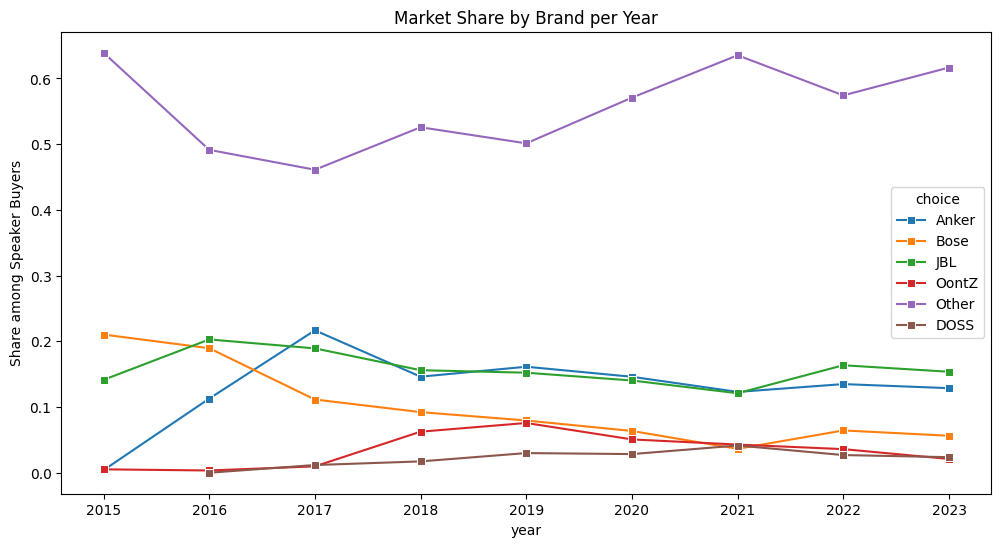

In [19]:
yearly_stats = df.groupby(['year', 'choice']).agg({
    'chosen_users': 'sum',
    'avg_price': 'mean',
    'share_among_speaker_buyers': 'sum'
}).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_stats, x='year', y='chosen_users', hue='choice', marker='o')
plt.title('Total Sales (Chosen Users) by Brand per Year')
plt.ylabel('Units Sold')
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_stats, x='year', y='share_among_speaker_buyers', hue='choice', marker='s')
plt.title('Market Share by Brand per Year')
plt.ylabel('Share among Speaker Buyers')
plt.show()

## Demand
- We typically think that product characteristics like price and features determines which product consumers purchase
- We don't observe the benefit or utility that corresponds to how much consumers like products, just the product they ultimately purchase; this is the latent variable being modeled
- This lends itself really well to multinomial logistic regression (but with a twist)
- This kind of model appears in economics in **industrial organization** and in business as **quantitative marketing**

## Demand Systems
- Imagine consumer $i$ deciding between different brands $j=1, 2, ... , J$ in period $t$, with prices $p_{j}$ and characteristics $x_{jt}$
- The **mean utility** provided by product $j$ to consumer $i$ is
$$
\delta_{jt} = b_0  + \sum_{\ell =1}^L b_\ell x_{jt\ell} + b_{\text{price}} p_{jt}
$$
- So consumers get an average benefit that depends on product characteristics, and then the price reduces that benefit
- When we add an error term and assume that it has the logistic distribution, this becomes multinomial logistic regression: Consumer $i$ gets a shock $\varepsilon_{ijt}$, and gets utilities for each brand $j$ of
$$
U_{ijt} = \delta_{ijt} + \varepsilon_{ijt} = b_0  + \sum_{\ell =1}^L b_\ell x_{jt\ell} + b_{\text{price}} p_{jt}+ \varepsilon_{ijt}
$$

## Demand Systems
- The product with the highest $U_{ijt}$ is the one they purchase, but market shares are determined by
$$
s_{jt} = \begin{cases} 
\frac{\exp(\delta_{jt})}{1 + \sum_{k=1}^{K-1} \exp(\delta_{kt})}, & k = 1, ..., K \\
\frac{1}{1 + \sum_{k=1}^{K-1}\exp(\delta_{kt})}, & \text{outside option}
\end{cases}
$$
- This is great: We just collect product and consumption data, and we can infer demand
- You *could* run this on the original consumer dataset with `.LogisticRegression()`, but that would be very unstable and take forever to converge

## Log-Linearizing the Demand System
- It turns out that estimating demand systems from millions of customers is extremely unstable
- Instead, we'll use a trick to reduce multinomial logistic regression to linear regression
- For the outside option, set $\delta_{Kt} = 0$; this is allowed, because we don't know the scale of the unobserved latent variable anyway -- we're just normalizing the "units" of the unobserved latent scale
- Now, notice that if we divide the share of any brand by demand for the outside option, we get
$$
\dfrac{s_{jt}}{s_{Kt}} = \frac{\exp(\delta_{jt})}{\exp(\delta_{Kt})}
$$
- Now take logs:
$$
\log(s_{jt}) - \log(s_{Kt}) = \delta_{jt} - \underbrace{\delta_{Kt}}_{=0}
$$


## Log-Linearizing the Demand System
- So, we can convert from consumer-level data to brand-level data, and estimate demand using product shares instead of individual consumer choices:
$$
\underbrace{\log(s_{jt}) - \log(s_{Kt})}_{\text{Difference in Log Shares}} = \underbrace{b_0  + \sum_{\ell =1}^L b_\ell x_{jt\ell} + b_{\text{price}} p_{jt}}_{\text{Linear Model}}
$$
- The regression we want to run is:
$$
\underbrace{\log(s_{jt}) - \log(s_{Kt})}_{\text{Difference in Log Shares}} = \underbrace{b_0  + \sum_{\ell =1}^L b_\ell x_{jt\ell} +  b_{\text{price}} p_{jt}}_{\text{Linear Model}}
$$
- So we just compute the log share differences on the left, and use it as our usual $y_{jt}$, and feature engineer the right-hand side
- Learning about consumer preferences and product positioning is **quantitative marketing**

## 2. Estimate the Demand System

Load `demand_3.parquet`. This is brand-level data, which is already consolidated from the consumer level data and aggregated across products sold by that brand.

- The log share differences are already computed, as `log_share_diff`
- Regress those values on price, waterproof flag, party flag, voice assistant flag, year dummies, average rating, and brand dummies

1. What is the coefficient on price? Is it negative? If the price is/were positive, does that make sense? Why might that happen?
2. Which brands have the highest coefficients?
3. Which features (waterproof, voice assistant, party) increase market share, which seem to decrease it?

In [20]:
df2 = pd.read_parquet('/Users/clairicelou/Documents/DS3021/undergrad_ml_assignments/data/demand_3.parquet')

df2.head()

,year,choice,chosen_users,avg_price,avg_rating,waterproof_share,party_share,voice_assistant_share,speaker_buyers,share_among_speaker_buyers,base_share,log_share_diff
0,2015,Anker,79,63.329873,4.529114,0.000000,0.0,0.000000,20029,0.003944,0.639173,-5.087909
1,2015,Bose,4212,141.189855,4.533974,0.000000,0.0,0.000000,20029,0.210295,0.639173,-1.111664
2,2015,JBL,2832,78.035332,4.383510,0.000353,0.0,0.000000,20029,0.141395,0.639173,-1.508618
3,2015,OontZ,104,45.456538,3.659615,0.000000,0.0,0.903846,20029,0.005192,0.639173,-4.812966
4,2016,Anker,2982,37.254859,4.679376,0.000000,0.0,0.000000,26429,0.112831,0.491354,-1.471278


In [25]:
from sklearn.linear_model import LinearRegression

y = df2['log_share_diff']

X_num = df.loc[:, ['avg_price', 'avg_rating', 'waterproof_share', 'party_share', 'voice_assistant_share']]
brand_ohc = pd.get_dummies(df['year'], dtype = int, drop_first = True, prefix = 'year')
year_ohc = pd.get_dummies(df['year'],dtype=int, drop_first=True, prefix='year')

X = pd.concat( [X_num, brand_ohc, year_ohc], axis=1)

reg = LinearRegression()
reg = reg.fit(X, y)

pd.DataFrame({'feature': reg.feature_names_in_,
              'coef': reg.coef_})

ValueError: Found input variables with inconsistent numbers of samples: [53, 44]

## Estimating Unit/Marginal Costs
- These firms pick their prices strategically, and price typically exceeds the true cost
- We want to understand how much the firms are making on each unit, in excess of the cost of creating it
- This is where economics begins: Do our markets maximize welfare? How much money are firms making by pricing strategically above cost? Are consumers exploited or not?
- The Amazon data are nice for data science purposes, but the same kind of analysis applies to education or epinephrine

## Inferring Cost
- How do we tie models to domain knowledge?
- Firm $j$ in period $t$ is maximizing its profits:
$$
\pi_{jt} = \underbrace{s_{jt}(p_{jt})}_{\text{Quantity Sold}} \quad \underbrace{(p_{jt}-c_{jt})}_{\text{Profit per Unit}}
$$
- That means that, at a maximum, it must be true that
$$
\pi_{jt}'(p_{jt}^*) = \underbrace{s_{jt}'(p_{jt}^*)(p_{jt}^*-c_{jt})}_{\text{Lost sales on the margin}} + \underbrace{s_{jt}(p_{jt}^*)}_{\text{Additional profits on remaining units sold}} = 0
$$
- If we re-arrange to solve for $c_{jt}$, we get
$$
\hat{c}_{jt} = p_{jt} + \dfrac{s_{jt}(p_{jt})}{s_{jt}'(p_{jt})}
$$
- This inverts demand and price to tell us about costs
- We can estimate the firm's unobserved, true cost of its product from demand behavior and prices
- Notice that price always exceeds marginal cost, here: Brands always price in excess of true cost

## Slope of Demand
- To keep things humane, I've pre-computed the derivative of the demand curve, like this:
$$
s_{jt}'(p_{jt}) = \frac{s_{jt}(p_{jt}+1)-s_{jt}(p_{jt}-1)}{2}
$$
- You can compute analytical derivatives using multinomial logistic regression, and GLM models in general provide us with dozens of ways to model and analyze how consumers respond to products

## 3. Market Fundamentals

Load `demand_4.parquet`. I've already computed $s_{jt}'(p_{jt})$ as `dprime`

- Compute the **unit cost** $\hat{c}_{jt}$ for each Brand in each period
- Compute the **mark-up** in each period, $markup_{jt} = p_{jt} - \hat{c}_{jt}$
- Compute the brand's **average profit** in each period, $ s_{jt} \times markup_{jt}$
- Make a kernel density plot of unit costs, mark-ups, and profits for each brand-year
- Which brands are most profitable? Which have the highest unit costs?
- Make scatter plots of price and unit cost, and average review and unit cost. Do you notice any patterns?

In [21]:
df3 = pd.read_parquet('/Users/clairicelou/Documents/DS3021/undergrad_ml_assignments/data/demand_4.parquet', engine = 'fastparquet')

df3.head()

,year,choice,avg_price,avg_rating,share_among_speaker_buyers,demand_users,dprime,revenue,elasticity,markup,marginal_cost,profit
0,2015,Anker,63.329873,4.529114,0.003944,82.558165,-4.986487,5228.398139,-3.823502,16.556379,46.773494,1366.864286
1,2015,Bose,141.189855,4.533974,0.210295,2068.180313,-112.445619,292006.078888,-6.758300,18.392716,122.797139,38039.452873
2,2015,JBL,78.035332,4.383510,0.141395,4898.509037,-224.283797,382256.778623,-4.061195,21.840673,56.194659,106986.733199
3,2015,OontZ,45.456538,3.659615,0.005192,119.327274,-7.193995,5424.204808,-2.740972,16.587066,28.869472,1979.289393
4,2016,Anker,37.254859,4.679376,0.112831,2187.746031,-121.670448,81504.170248,-2.003358,17.980915,19.273944,39337.676322


In [ ]:
df2['uc'] = df2['avg_price'] + df2['share_among_speaker_buyers']/df2['dprime']
df3['markup'] = df['avg_price'] - df['uc']
sns.kdeplot(df['markup'], hue=df['choice'],common_norm=False)

## 4. Welfare
The DOJ and FTC use these kinds of models for anti-trust investigations. Online commerce is the target of recent FTC regulatory actions, in particular towards Amazon. 

1. Do you think this market is relatively competitive?
2. Are the mark-ups sizeable? Are they worth pursuing regulatory or industrial policy over, or even an anti-trust lawsuit?
3. The bigger picture question is: "What is the market definition, and what products should be included?" The broader the market defintion, the more finely demand and sales are split, and the less power every firm appears to have (e.g. baseball; professional sports; entertainment). If you had to defend the brands we analyzed, what argument would you make?